In [20]:
import pandas as pd # process and manipulate table data, implementing operations such as loading, aligning, merging, and transforming datasets efficiently
import numpy as np # numerical computing library for working with arrays and matrices, providing mathematical functions to operate on these data structures
import matplotlib.pyplot as plt # plotting library for creating static, animated, and interactive visualizations in Python
import os   # operating system interfaces for file and directory manipulation
import warnings # warning control to suppress or manage warning messages

from tkinter import Tk # standard GUI library for Python, used here to create file dialog windows
from tkinter.filedialog import askopenfilenames # function to open file dialog for selecting multiple files

# Suppress pandas parsing warnings
warnings.filterwarnings('ignore', message="Could not infer format") 

Loading and processing rainfall data...
  CORMP: 635 hourly records
  Davis: 633 hourly records
  rainfall_0000: 685 hourly records

Filtering to period: 2025-12-19 09:00:00 to 2026-01-14 11:00:00
  CORMP (filtered): 627 records
  Davis (filtered): 624 records
  rainfall_0000 (filtered): 626 records


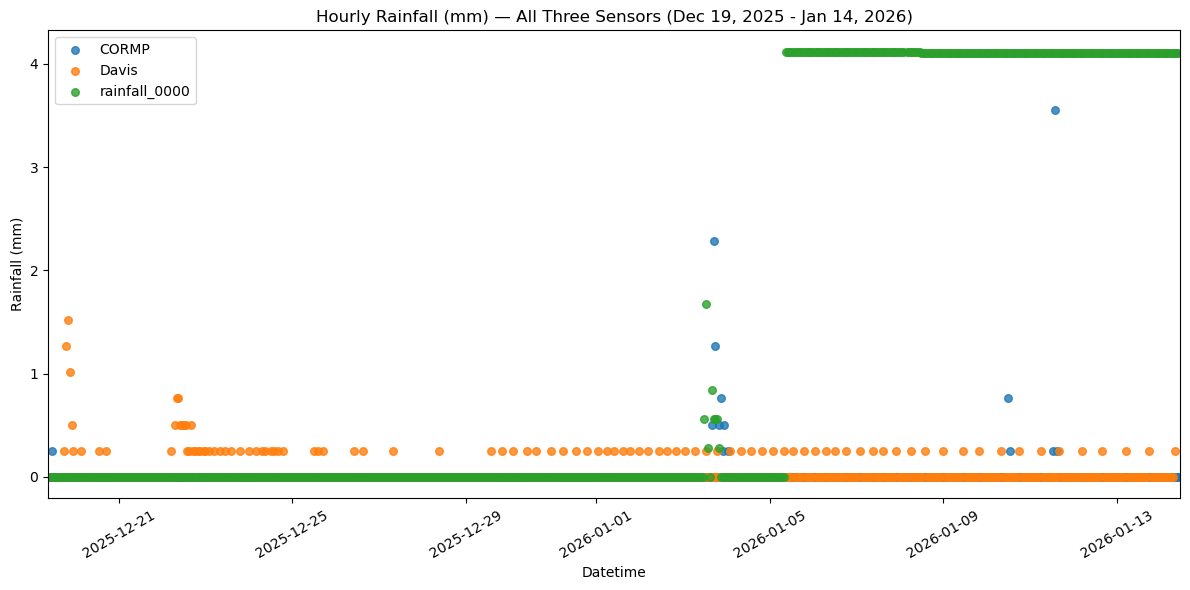

In [21]:

# STEP 1: Define file paths and helper functions
# Earliest data from rainfall_0000 is Dec 19, 2025, therefore all graphs begin at this time stamp.
file_1 = "Data/precip_CORMP_01142026.csv"   # needs hourly sum
file_2 = "Data/precip_Davis_01142026.csv"   # needs hourly sum
file_3 = "Data/rainfall_0000_01142026.csv"   # already hourly

import io # for in-memory file operations
import re # for regular expressions

# detects header row by looking for keywords in the first max_lines (200) lines
# looking for for keywords like 'date' or 'time', combined with a comma (typical CSV header indicator).
def detect_header_row(path, max_lines=200):
    with open(path, 'r', encoding='utf-8', errors='ignore') as fh:
        for i, line in enumerate(fh):
            if i >= max_lines:
                break
            low = line.lower()
            # looking for header lines usually contain 'date' or 'time' and a comma
            if (('date' in low or 'time' in low) and ',' in line) or ('date &' in low):
                return i
    return 0


# Load and process rainfall_0 CSV file with "smart column detection". Returns data from datetime and rainfall 
# Converts units if needed, and resamples to hourly aggregates.
def load_and_process(filepath, assume_inches=False, already_hourly=False):
    path = os.path.join(filepath)
    header_row = detect_header_row(path, max_lines=200)
    try:
        # set header to detected row; also skip percent-comment lines
        df = pd.read_csv(path, header=header_row, comment='%', engine='python')
    except Exception as e:
        print(f"read_csv failed for {path}: {e}")
        df = pd.read_csv(path, engine='python', sep=None, on_bad_lines='warn')

    # ensure column names are strings
    df.columns = [str(c) for c in df.columns]

    # find datetime column by keywords or by attempting to parse columns
    datetime_cols = [c for c in df.columns if any(k in c.lower() for k in ('date','time','datetime','timestamp'))]
    dtcol = None
    if datetime_cols: # found by keyword
        dtcol = datetime_cols[0]
    else:
        for c in df.columns:
            try:
                parsed = pd.to_datetime(df[c], errors='coerce') # try to parse as datetime
                if parsed.notna().sum() > 0: # at least some valid datetimes
                    dtcol = c
                    break
            except Exception:
                continue
    if dtcol is None:
        raise ValueError(f"No datetime-like column found in {filepath}")

    df['datetime'] = pd.to_datetime(df[dtcol], errors='coerce')

    # find rainfall column
    rain_cols = [c for c in df.columns if any(k in c.lower() for k in ('rain','precip','mm','inches'))]
    if rain_cols:
        rcol = rain_cols[0]
    else:
        numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        rcol = numeric_cols[0] if numeric_cols else None

    if rcol is None:
        for c in df.columns:
            coerced = pd.to_numeric(df[c], errors='coerce')
            if coerced.notna().sum() > 0:
                rcol = c
                df[c] = coerced
                break
    if rcol is None:
        raise ValueError(f"No rainfall/numeric column found in {filepath}")

    df[rcol] = pd.to_numeric(df[rcol], errors='coerce')
    if assume_inches:
        df[rcol] = df[rcol] * 25.4

    subset_cols = [c for c in ['datetime', rcol] if c in df.columns]
    df = df.dropna(subset=subset_cols)

    if 'datetime' in df.columns:
        df = df.set_index('datetime')
    else:
        if not isinstance(df.index, pd.DatetimeIndex):
            raise KeyError('datetime')

    if already_hourly:
        hourly = df.reset_index().rename(columns={rcol: 'rain_mm'})
        if 'datetime' not in hourly.columns:
            hourly = hourly.rename(columns={hourly.columns[0]: 'datetime'})
    else:
        hourly = df[rcol].resample('h').sum().reset_index().rename(columns={rcol: 'rain_mm'})
    return hourly


# STEP 2: Load and process all three rainfall files

print("Loading and processing rainfall data...")
cormp = load_and_process(file_1, assume_inches=True, already_hourly=False)
davis = load_and_process(file_2, assume_inches=True, already_hourly=False)
rain0 = load_and_process(file_3, assume_inches=False, already_hourly=True)

print(f"  CORMP: {len(cormp)} hourly records")
print(f"  Davis: {len(davis)} hourly records")
print(f"  rainfall_0000: {len(rain0)} hourly records")


# STEP 3: Filter to the analysis date range (Dec 19, 2025 - Jan 6, 2026)

start = pd.to_datetime('2025-12-19 09:00')
end = pd.to_datetime('2026-01-14 11:00')

print(f"\nFiltering to period: {start} to {end}")

cormp = cormp[(cormp['datetime'] >= start) & (cormp['datetime'] <= end)].reset_index(drop=True)
davis = davis[(davis['datetime'] >= start) & (davis['datetime'] <= end)].reset_index(drop=True)
rain0 = rain0[(rain0['datetime'] >= start) & (rain0['datetime'] <= end)].reset_index(drop=True)

print(f"  CORMP (filtered): {len(cormp)} records")
print(f"  Davis (filtered): {len(davis)} records")
print(f"  rainfall_0000 (filtered): {len(rain0)} records")

# STEP 4: Plot - All three sensors over full date range

plt.figure(figsize=(12,6))
if not cormp.empty:
    plt.scatter(cormp['datetime'], cormp['rain_mm'], label='CORMP', s=30, alpha=0.8)
if not davis.empty:
    plt.scatter(davis['datetime'], davis['rain_mm'], label='Davis', s=30, alpha=0.8)
if not rain0.empty:
    plt.scatter(rain0['datetime'], rain0['rain_mm'], label='rainfall_0000', s=30, alpha=0.8)

plt.xlabel('Datetime')
plt.ylabel('Rainfall (mm)')
plt.title('Hourly Rainfall (mm) — All Three Sensors (Dec 19, 2025 - Jan 14, 2026)')
plt.legend()
plt.xlim(start, end)

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


Filtering January 3rd data...
  CORMP: 24 hourly records
  Davis: 24 hourly records
  rainfall_0000: 24 hourly records


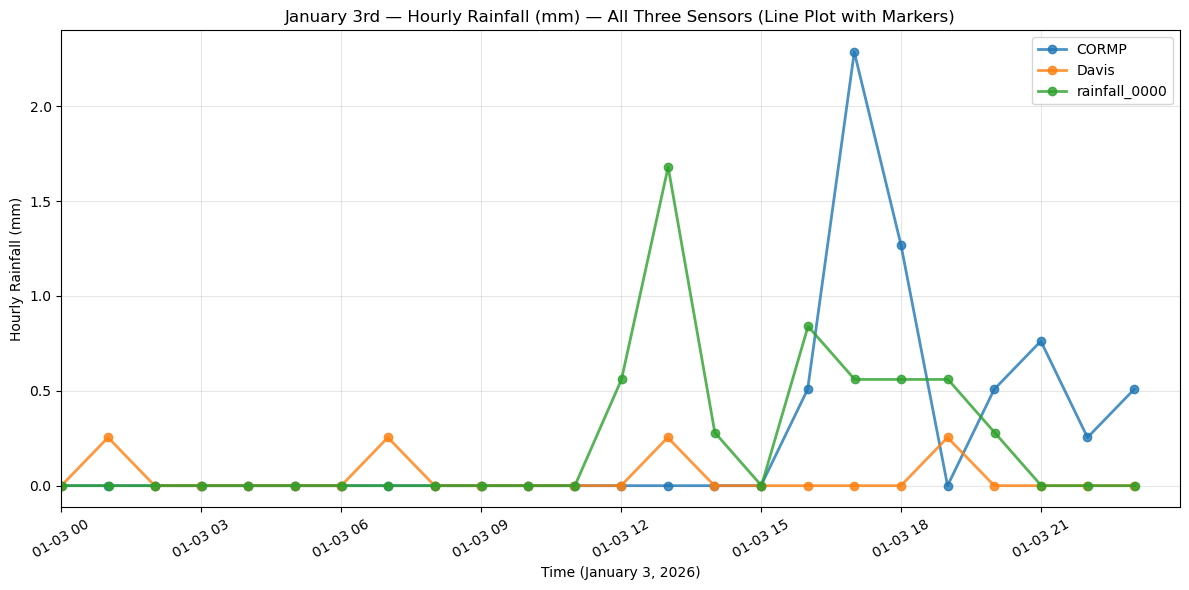

In [13]:

# View of January 3rd, 2026 — All three sensors

jan3_start = pd.to_datetime('2026-01-03 00:00')
jan3_end = pd.to_datetime('2026-01-03 23:59')

print("Filtering January 3rd data...")
cormp_jan3 = cormp[(cormp['datetime'] >= jan3_start) & (cormp['datetime'] <= jan3_end)].reset_index(drop=True)
davis_jan3 = davis[(davis['datetime'] >= jan3_start) & (davis['datetime'] <= jan3_end)].reset_index(drop=True)
rain0_jan3 = rain0[(rain0['datetime'] >= jan3_start) & (rain0['datetime'] <= jan3_end)].reset_index(drop=True)

print(f"  CORMP: {len(cormp_jan3)} hourly records")
print(f"  Davis: {len(davis_jan3)} hourly records")
print(f"  rainfall_0000: {len(rain0_jan3)} hourly records")

plt.figure(figsize=(12,6))
if not cormp_jan3.empty:
    plt.plot(cormp_jan3['datetime'], cormp_jan3['rain_mm'], label='CORMP', marker='o', linewidth=2, markersize=6, alpha=0.8)
if not davis_jan3.empty:
    plt.plot(davis_jan3['datetime'], davis_jan3['rain_mm'], label='Davis', marker='o', linewidth=2, markersize=6, alpha=0.8)
if not rain0_jan3.empty:
    plt.plot(rain0_jan3['datetime'], rain0_jan3['rain_mm'], label='rainfall_0000', marker='o', linewidth=2, markersize=6, alpha=0.8)

plt.xlabel('Time (January 3, 2026)')
plt.ylabel('Hourly Rainfall (mm)')
plt.title('January 3rd — Hourly Rainfall (mm) — All Three Sensors (Line Plot with Markers)')
plt.legend()
plt.xlim(jan3_start, jan3_end)
plt.xticks(rotation=30)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


ANALYSIS 2: Davis vs rainfall_0000 Comparison

Before datetime alignment:
  Davis shape: (624, 2)
  rainfall_0000 shape: (626, 11)

Overlapping hourly timestamps: 623 hours
Merged dataset shape: (624, 12)


C:\Users\ppita\AppData\Local\Temp\ipykernel_36680\4076861592.py:25: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  davis_only['datetime'] = davis_only['datetime'].dt.floor('H')
C:\Users\ppita\AppData\Local\Temp\ipykernel_36680\4076861592.py:26: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  rain0_only['datetime'] = rain0_only['datetime'].dt.floor('H')



Pearson Correlation: -0.1155
R² (Coefficient of Determination): 0.0133
RMSE (Root Mean Square Error): 2.4042 mm
Slope: -1.5301

Generating scatter plot...
  Plotted 624 data points


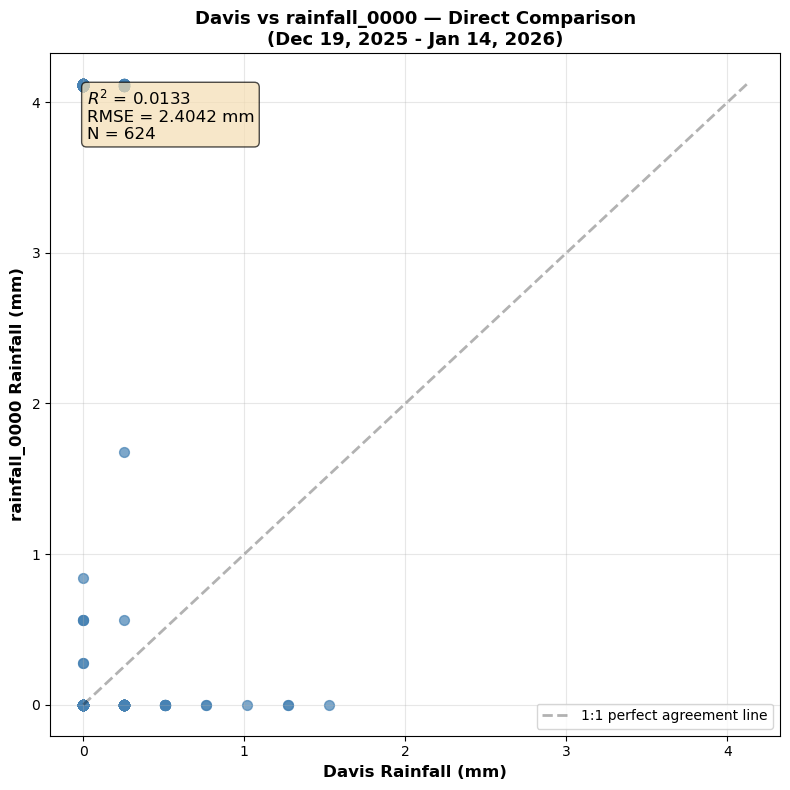

In [15]:

# Davis vs rainfall_0000 — Direct Sensor Comparison
# Merge datasets by datetime, compute correlation (R²), and plot


print("=" * 70)
print("ANALYSIS 2: Davis vs rainfall_0000 Comparison")
print("=" * 70)

# Reload and process both datasets for clean analysis
davis_only = load_and_process(file_2, assume_inches=True, already_hourly=False)
rain0_only = load_and_process(file_3, assume_inches=False, already_hourly=True)

start = pd.to_datetime('2025-12-19 09:00')
end = pd.to_datetime('2026-01-14 11:00')

davis_only = davis_only[(davis_only['datetime'] >= start) & (davis_only['datetime'] <= end)].reset_index(drop=True)
rain0_only = rain0_only[(rain0_only['datetime'] >= start) & (rain0_only['datetime'] <= end)].reset_index(drop=True)

print(f"\nBefore datetime alignment:")
print(f"  Davis shape: {davis_only.shape}")
print(f"  rainfall_0000 shape: {rain0_only.shape}")

# Round both to nearest HOUR to align hourly data (discard minutes and seconds)
# This ensures datasets can be merged properly on datetime
davis_only['datetime'] = davis_only['datetime'].dt.floor('H')
rain0_only['datetime'] = rain0_only['datetime'].dt.floor('H')

# Check for overlapping datetimes
davis_dates = set(davis_only['datetime'])
rain0_dates = set(rain0_only['datetime'])
overlap = davis_dates.intersection(rain0_dates)
print(f"\nOverlapping hourly timestamps: {len(overlap)} hours")

# Align datasets on datetime for direct comparison
merged_dr_only = pd.merge(davis_only, rain0_only, on='datetime', how='inner', suffixes=('_davis','_rain0'))
print(f"Merged dataset shape: {merged_dr_only.shape}")

# Compute correlation, R², RMSE, and slope
if not merged_dr_only.empty:
    from scipy import stats
    corr_only = merged_dr_only['rain_mm_davis'].corr(merged_dr_only['rain_mm_rain0'])
    r2_only = corr_only**2 if pd.notna(corr_only) else float('nan')
    # Calculate RMSE (Root Mean Square Error)
    mse = np.mean((merged_dr_only['rain_mm_davis'] - merged_dr_only['rain_mm_rain0'])**2)
    rmse_only = np.sqrt(mse)
    # Calculate slope via linear regression
    slope_only, intercept_only, _, _, _ = stats.linregress(merged_dr_only['rain_mm_davis'], merged_dr_only['rain_mm_rain0'])
    print(f"\nPearson Correlation: {corr_only:.4f}")
    print(f"R² (Coefficient of Determination): {r2_only:.4f}")
    print(f"RMSE (Root Mean Square Error): {rmse_only:.4f} mm")
    print(f"Slope: {slope_only:.4f}")
else:
    r2_only = float('nan')
    rmse_only = float('nan')
    slope_only = float('nan')
    print("No overlapping data found!")

# Create scatter plot: Davis (X-axis) vs rainfall_0000 (Y-axis)
print(f"\nGenerating scatter plot...")
plt.figure(figsize=(8,8))
if not merged_dr_only.empty:
    plt.scatter(merged_dr_only['rain_mm_davis'], merged_dr_only['rain_mm_rain0'], s=50, alpha=0.7, color='steelblue')
    print(f"  Plotted {len(merged_dr_only)} data points")
else:
    print("  No data to plot - no overlapping datetimes found")

plt.xlabel('Davis Rainfall (mm)', fontsize=12, fontweight='bold')
plt.ylabel('rainfall_0000 Rainfall (mm)', fontsize=12, fontweight='bold')
plt.title('Davis vs rainfall_0000 — Direct Comparison\n(Dec 19, 2025 - Jan 14, 2026)', fontsize=13, fontweight='bold')

# Annotate R² and RMSE on plot
try:
    ax = plt.gca()
    if pd.notna(r2_only) and not merged_dr_only.empty:
        ax.text(0.05, 0.95, f'$R^2$ = {r2_only:.4f}\nRMSE = {rmse_only:.4f} mm\nN = {len(merged_dr_only)}', 
                transform=ax.transAxes, fontsize=12, va='top', 
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))
except Exception as e:
    print(f"Warning: Could not annotate plot: {e}")

if not merged_dr_only.empty:
    max_val = max(merged_dr_only['rain_mm_davis'].max(), merged_dr_only['rain_mm_rain0'].max())
    plt.plot([0, max_val], [0, max_val], 'k--', alpha=0.3, linewidth=2, label='1:1 perfect agreement line')
    plt.legend(loc='lower right')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


ANALYSIS 2B: Davis vs rainfall_0000 Comparison (Non-Zero Values Only)

Filtered dataset shape (non-zero only): (26, 12)
Original dataset had 624 rows, now have 26 rows

Pearson Correlation: 0.0000
R² (Coefficient of Determination): 0.0000
RMSE (Root Mean Square Error): 3.7201 mm

Generating scatter plot...
  Plotted 26 data points


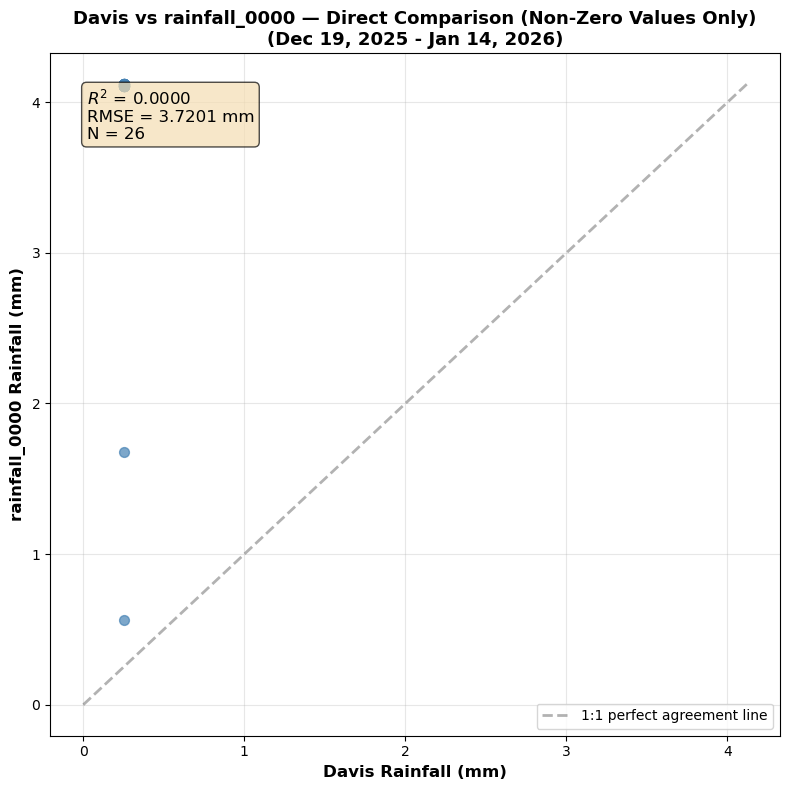

In [17]:

# Davis vs rainfall_0000 — Direct Sensor Comparison (EXCLUDING ZERO VALUES)
# Merge datasets by datetime, compute correlation (R²), and plot


print("=" * 70)
print("ANALYSIS 2B: Davis vs rainfall_0000 Comparison (Non-Zero Values Only)")
print("=" * 70)

# Use the already-merged dataset from Analysis 2
# Filter to exclude rows where either sensor has zero rainfall
merged_dr_nonzero = merged_dr_only[
    (merged_dr_only['rain_mm_davis'] > 0) & 
    (merged_dr_only['rain_mm_rain0'] > 0)
].reset_index(drop=True)

print(f"\nFiltered dataset shape (non-zero only): {merged_dr_nonzero.shape}")
print(f"Original dataset had {len(merged_dr_only)} rows, now have {len(merged_dr_nonzero)} rows")

# Compute correlation, R², and RMSE for non-zero data
if not merged_dr_nonzero.empty:
    corr_nonzero = merged_dr_nonzero['rain_mm_davis'].corr(merged_dr_nonzero['rain_mm_rain0'])
    r2_nonzero = corr_nonzero**2 if pd.notna(corr_nonzero) else float('nan')
    # Calculate RMSE (Root Mean Square Error)
    mse_nonzero = np.mean((merged_dr_nonzero['rain_mm_davis'] - merged_dr_nonzero['rain_mm_rain0'])**2)
    rmse_nonzero = np.sqrt(mse_nonzero)
    print(f"\nPearson Correlation: {corr_nonzero:.4f}")
    print(f"R² (Coefficient of Determination): {r2_nonzero:.4f}")
    print(f"RMSE (Root Mean Square Error): {rmse_nonzero:.4f} mm")
else:
    r2_nonzero = float('nan')
    rmse_nonzero = float('nan')
    print("No non-zero overlapping data found!")

# Create scatter plot: Davis (X-axis) vs rainfall_0000 (Y-axis)
print(f"\nGenerating scatter plot...")
plt.figure(figsize=(8,8))
if not merged_dr_nonzero.empty:
    plt.scatter(merged_dr_nonzero['rain_mm_davis'], merged_dr_nonzero['rain_mm_rain0'], s=50, alpha=0.7, color='steelblue')
    print(f"  Plotted {len(merged_dr_nonzero)} data points")
else:
    print("  No data to plot - no non-zero overlapping datetimes found")

plt.xlabel('Davis Rainfall (mm)', fontsize=12, fontweight='bold')
plt.ylabel('rainfall_0000 Rainfall (mm)', fontsize=12, fontweight='bold')
plt.title('Davis vs rainfall_0000 — Direct Comparison (Non-Zero Values Only)\n(Dec 19, 2025 - Jan 14, 2026)', fontsize=13, fontweight='bold')

# add 1:1 reference line (perfect agreement)
if not merged_dr_nonzero.empty:
    max_val = max(merged_dr_nonzero['rain_mm_davis'].max(), merged_dr_nonzero['rain_mm_rain0'].max())
    plt.plot([0, max_val], [0, max_val], 'k--', alpha=0.3, linewidth=2, label='1:1 perfect agreement line')

# Annotate R² and RMSE on plot
try:
    ax = plt.gca()
    if pd.notna(r2_nonzero) and not merged_dr_nonzero.empty:
        ax.text(0.05, 0.95, f'$R^2$ = {r2_nonzero:.4f}\nRMSE = {rmse_nonzero:.4f} mm\nN = {len(merged_dr_nonzero)}', 
                transform=ax.transAxes, fontsize=12, va='top', 
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))
except Exception as e:
    print(f"Warning: Could not annotate plot: {e}")

if not merged_dr_nonzero.empty:
    plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


ANALYSIS 3: rainfall_0000 vs precip_CORMP Comparison

Before datetime alignment:
  CORMP shape: (627, 2)
  rainfall_0000 shape: (626, 11)

After rounding to nearest hour:
  CORMP first 5 timestamps: [Timestamp('2025-12-19 09:00:00'), Timestamp('2025-12-19 10:00:00'), Timestamp('2025-12-19 11:00:00'), Timestamp('2025-12-19 12:00:00'), Timestamp('2025-12-19 13:00:00')]
  rainfall_0000 first 5 timestamps: [Timestamp('2025-12-19 09:00:00'), Timestamp('2025-12-19 10:00:00'), Timestamp('2025-12-19 11:00:00'), Timestamp('2025-12-19 12:00:00'), Timestamp('2025-12-19 13:00:00')]

Overlapping hourly timestamps: 625 hours
Merged dataset shape: (626, 12)

Pearson Correlation: 0.0294
R² (Coefficient of Determination): 0.0009
Slope: 0.0028

Generating scatter plot...
  Plotted 626 data points


C:\Users\ppita\AppData\Local\Temp\ipykernel_36680\2948174000.py:23: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  cormp_only['datetime'] = cormp_only['datetime'].dt.floor('H')
C:\Users\ppita\AppData\Local\Temp\ipykernel_36680\2948174000.py:24: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  rain0_cormp['datetime'] = rain0_cormp['datetime'].dt.floor('H')


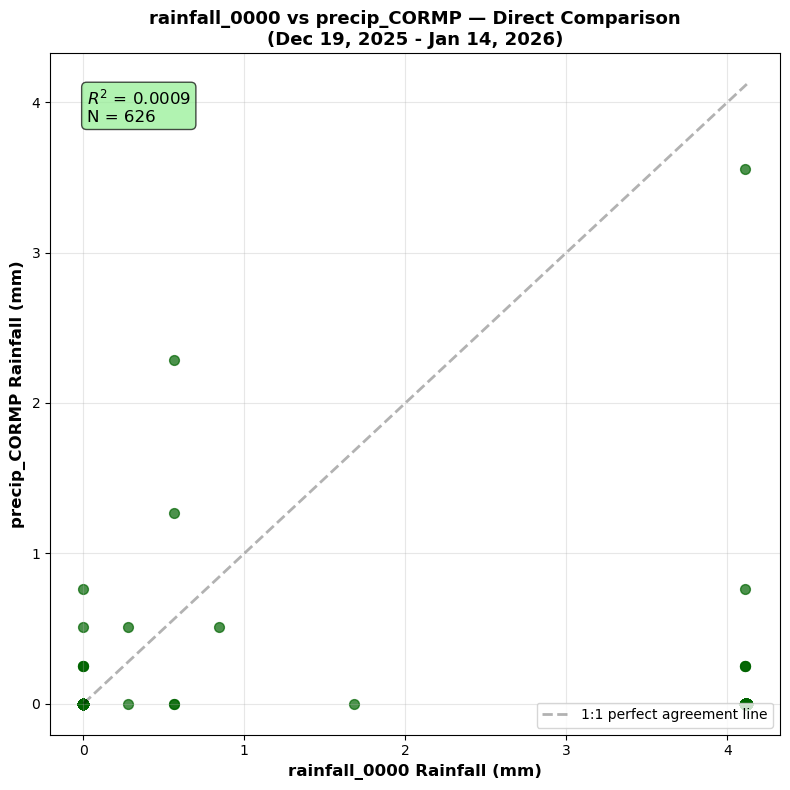

In [18]:
# Rainfall_0000 vs precip_CORMP — Direct Sensor Comparison
# Merge datasets by datetime, compute correlation (R²), and plot

print("=" * 70)
print("ANALYSIS 3: rainfall_0000 vs precip_CORMP Comparison")
print("=" * 70)

# Reload and process both datasets for clean analysis
cormp_only = load_and_process(file_1, assume_inches=True, already_hourly=False)
rain0_cormp = load_and_process(file_3, assume_inches=False, already_hourly=True)

start = pd.to_datetime('2025-12-19 09:00')
end = pd.to_datetime('2026-01-14 11:00')

cormp_only = cormp_only[(cormp_only['datetime'] >= start) & (cormp_only['datetime'] <= end)].reset_index(drop=True)
rain0_cormp = rain0_cormp[(rain0_cormp['datetime'] >= start) & (rain0_cormp['datetime'] <= end)].reset_index(drop=True)

print(f"\nBefore datetime alignment:")
print(f"  CORMP shape: {cormp_only.shape}")
print(f"  rainfall_0000 shape: {rain0_cormp.shape}")

# Round both to nearest HOUR to align hourly data (discard minutes and seconds)
cormp_only['datetime'] = cormp_only['datetime'].dt.floor('H')
rain0_cormp['datetime'] = rain0_cormp['datetime'].dt.floor('H')

print(f"\nAfter rounding to nearest hour:")
print(f"  CORMP first 5 timestamps: {cormp_only['datetime'].head().tolist()}")
print(f"  rainfall_0000 first 5 timestamps: {rain0_cormp['datetime'].head().tolist()}")

# Check for overlapping datetimes
cormp_dates = set(cormp_only['datetime'])
rain0_dates = set(rain0_cormp['datetime'])
overlap = cormp_dates.intersection(rain0_dates)
print(f"\nOverlapping hourly timestamps: {len(overlap)} hours")

# Align datasets on datetime for direct comparison
merged_cr_only = pd.merge(rain0_cormp, cormp_only, on='datetime', how='inner', suffixes=('_rain0','_cormp'))
print(f"Merged dataset shape: {merged_cr_only.shape}")

# Compute correlation, R², and slope
if not merged_cr_only.empty:
    from scipy import stats
    corr_cr = merged_cr_only['rain_mm_rain0'].corr(merged_cr_only['rain_mm_cormp'])
    r2_cr = corr_cr**2 if pd.notna(corr_cr) else float('nan')
    # Calculate slope via linear regression
    slope_cr, intercept_cr, _, _, _ = stats.linregress(merged_cr_only['rain_mm_rain0'], merged_cr_only['rain_mm_cormp'])
    print(f"\nPearson Correlation: {corr_cr:.4f}")
    print(f"R² (Coefficient of Determination): {r2_cr:.4f}")
    print(f"Slope: {slope_cr:.4f}")
else:
    r2_cr = float('nan')
    slope_cr = float('nan')
    print("No overlapping data found!")

# Create scatter plot: rainfall_0000 (X-axis) vs precip_CORMP (Y-axis)
print(f"\nGenerating scatter plot...")
plt.figure(figsize=(8,8))
if not merged_cr_only.empty:
    plt.scatter(merged_cr_only['rain_mm_rain0'], merged_cr_only['rain_mm_cormp'], s=50, alpha=0.7, color='darkgreen')
    print(f"  Plotted {len(merged_cr_only)} data points")
else:
    print("  No data to plot - no overlapping datetimes found")

plt.xlabel('rainfall_0000 Rainfall (mm)', fontsize=12, fontweight='bold')
plt.ylabel('precip_CORMP Rainfall (mm)', fontsize=12, fontweight='bold')
plt.title('rainfall_0000 vs precip_CORMP — Direct Comparison\n(Dec 19, 2025 - Jan 14, 2026)', fontsize=13, fontweight='bold')

# Annotate R² on plot
try:
    ax = plt.gca()
    if pd.notna(r2_cr) and not merged_cr_only.empty:
        ax.text(0.05, 0.95, f'$R^2$ = {r2_cr:.4f}\nN = {len(merged_cr_only)}', 
                transform=ax.transAxes, fontsize=12, va='top', 
                bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))
except Exception as e:
    print(f"Warning: Could not annotate plot: {e}")

if not merged_cr_only.empty:
    max_val = max(merged_cr_only['rain_mm_rain0'].max(), merged_cr_only['rain_mm_cormp'].max())
    plt.plot([0, max_val], [0, max_val], 'k--', alpha=0.3, linewidth=2, label='1:1 perfect agreement line')
    plt.legend(loc='lower right')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


ANALYSIS 4: precip_Davis vs precip_CORMP Comparison

Before datetime alignment:
  Davis shape: (624, 2)
  CORMP shape: (627, 2)

After rounding to nearest hour:
  Davis first 5 timestamps: [Timestamp('2025-12-19 09:00:00'), Timestamp('2025-12-19 10:00:00'), Timestamp('2025-12-19 11:00:00'), Timestamp('2025-12-19 12:00:00'), Timestamp('2025-12-19 13:00:00')]
  CORMP first 5 timestamps: [Timestamp('2025-12-19 09:00:00'), Timestamp('2025-12-19 10:00:00'), Timestamp('2025-12-19 11:00:00'), Timestamp('2025-12-19 12:00:00'), Timestamp('2025-12-19 13:00:00')]

Overlapping hourly timestamps: 624 hours
Merged dataset shape: (624, 3)

Pearson Correlation: -0.0363
R² (Coefficient of Determination): 0.0013
Slope: -0.0486

Generating scatter plot...
  Plotted 624 data points


C:\Users\ppita\AppData\Local\Temp\ipykernel_36680\535300473.py:22: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  davis_cormp['datetime'] = davis_cormp['datetime'].dt.floor('H')
C:\Users\ppita\AppData\Local\Temp\ipykernel_36680\535300473.py:23: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  cormp_davis['datetime'] = cormp_davis['datetime'].dt.floor('H')


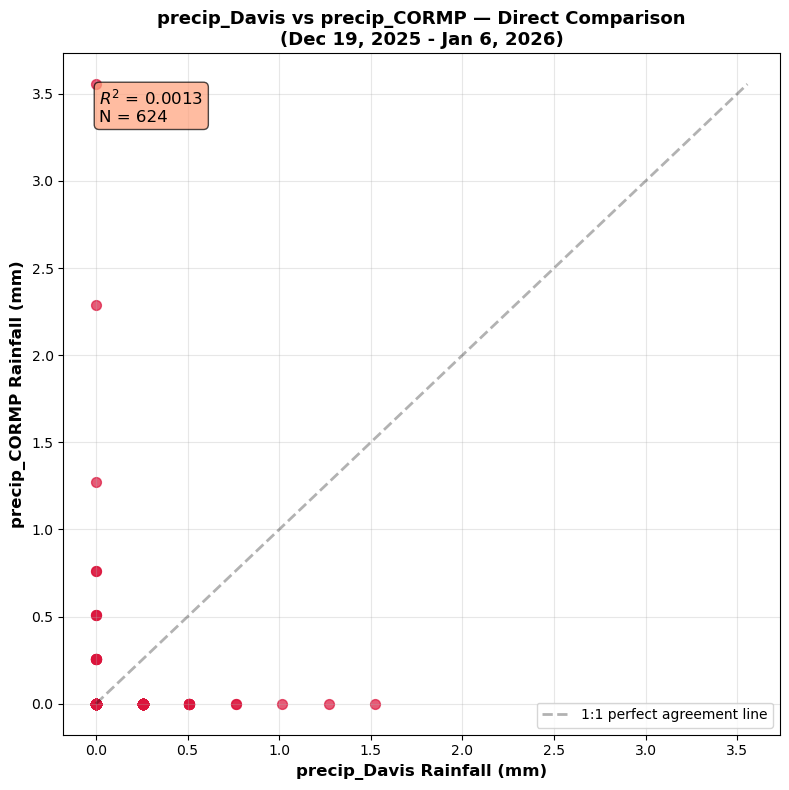

In [ ]:
# precip_Davis vs precip_CORMP — Direct Sensor Comparison

print("=" * 70)
print("ANALYSIS 4: precip_Davis vs precip_CORMP Comparison")
print("=" * 70)

# Reload and process both datasets for clean analysis
davis_cormp = load_and_process(file_2, assume_inches=True, already_hourly=False)
cormp_davis = load_and_process(file_1, assume_inches=True, already_hourly=False)

start = pd.to_datetime('2025-12-19 09:00')
end = pd.to_datetime('2026-01-14 11:00')

davis_cormp = davis_cormp[(davis_cormp['datetime'] >= start) & (davis_cormp['datetime'] <= end)].reset_index(drop=True)
cormp_davis = cormp_davis[(cormp_davis['datetime'] >= start) & (cormp_davis['datetime'] <= end)].reset_index(drop=True)

print(f"\nBefore datetime alignment:")
print(f"  Davis shape: {davis_cormp.shape}")
print(f"  CORMP shape: {cormp_davis.shape}")

# Round both to nearest HOUR to align hourly data (discard minutes and seconds)
davis_cormp['datetime'] = davis_cormp['datetime'].dt.floor('H')
cormp_davis['datetime'] = cormp_davis['datetime'].dt.floor('H')

print(f"\nAfter rounding to nearest hour:")
print(f"  Davis first 5 timestamps: {davis_cormp['datetime'].head().tolist()}")
print(f"  CORMP first 5 timestamps: {cormp_davis['datetime'].head().tolist()}")

# Check for overlapping datetimes
davis_dates = set(davis_cormp['datetime'])
cormp_dates = set(cormp_davis['datetime'])
overlap = davis_dates.intersection(cormp_dates)
print(f"\nOverlapping hourly timestamps: {len(overlap)} hours")

# Align datasets on datetime for direct comparison
merged_dc_only = pd.merge(davis_cormp, cormp_davis, on='datetime', how='inner', suffixes=('_davis','_cormp'))
print(f"Merged dataset shape: {merged_dc_only.shape}")

# Compute correlation, R², and slope
if not merged_dc_only.empty:
    from scipy import stats
    corr_dc = merged_dc_only['rain_mm_davis'].corr(merged_dc_only['rain_mm_cormp'])
    r2_dc = corr_dc**2 if pd.notna(corr_dc) else float('nan')
    # Calculate slope via linear regression
    slope_dc, intercept_dc, _, _, _ = stats.linregress(merged_dc_only['rain_mm_davis'], merged_dc_only['rain_mm_cormp'])
    print(f"\nPearson Correlation: {corr_dc:.4f}")
    print(f"R² (Coefficient of Determination): {r2_dc:.4f}")
    print(f"Slope: {slope_dc:.4f}")
else:
    r2_dc = float('nan')
    slope_dc = float('nan')
    print("No overlapping data found!")

# Create scatter plot: precip_Davis (X-axis) vs precip_CORMP (Y-axis)
print(f"\nGenerating scatter plot...")
plt.figure(figsize=(8,8))
if not merged_dc_only.empty:
    plt.scatter(merged_dc_only['rain_mm_davis'], merged_dc_only['rain_mm_cormp'], s=50, alpha=0.7, color='crimson')
    print(f"  Plotted {len(merged_dc_only)} data points")
else:
    print("  No data to plot - no overlapping datetimes found")

plt.xlabel('precip_Davis Rainfall (mm)', fontsize=12, fontweight='bold')
plt.ylabel('precip_CORMP Rainfall (mm)', fontsize=12, fontweight='bold')
plt.title('precip_Davis vs precip_CORMP — Direct Comparison\n(Dec 19, 2025 - Jan 6, 2026)', fontsize=13, fontweight='bold')

# Annotate R² on plot
try:
    ax = plt.gca() # get current axes
    if pd.notna(r2_dc) and not merged_dc_only.empty:
        ax.text(0.05, 0.95, f'$R^2$ = {r2_dc:.4f}\nN = {len(merged_dc_only)}', 
                transform=ax.transAxes, fontsize=12, va='top', 
                bbox=dict(boxstyle='round', facecolor='lightsalmon', alpha=0.7))
except Exception as e:
    print(f"Warning: Could not annotate plot: {e}")

if not merged_dc_only.empty:
    max_val = max(merged_dc_only['rain_mm_davis'].max(), merged_dc_only['rain_mm_cormp'].max())
    plt.plot([0, max_val], [0, max_val], 'k--', alpha=0.3, linewidth=2, label='1:1 perfect agreement line')
    plt.legend(loc='lower right')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


R^2 (Davis vs rainfall_0000) [main plot]: nan
R^2 (Davis vs rainfall_0000) [Davis-only plot]: nan
